In [3]:
import pandas as pd

kb_data = [
    [2022, "AI", "AI은행원·AI금융비서·AI-OCR·기업여신 자동심사", "업무 적용"],
    [2022, "Digital Platform", "AI 챗봇·클라우드 기반 FCC 구축", "인프라 구축"],
    [2022, "Blockchain", "블록체인 기술협력", "기술 탐색"],
    
    [2023, "AI/Data", "상담 STT·TA에 AI·빅데이터 적용", "업무 확장"],
    
    [2025, "Digital Asset", "빗썸 실명확인 입출금계정 서비스", "서비스 연결"],
    [2025, "AI", "AI 검색·AI 브리핑 등 고객서비스 확대", "서비스 확대"],
    
    [2026, "Token Infrastructure", "예금토큰 기반 결제 인프라 참여", "실증"],
    [2026, "Digital Asset", "스테이블코인·RWA 수탁·지갑·브릿지 인프라 개발", "사업 준비"]
]

df_kb = pd.DataFrame(
    kb_data,
    columns=["year", "business_axis", "evidence", "stage"]
)

display(df_kb)

,year,business_axis,evidence,stage
0,2022,AI,AI은행원·AI금융비서·AI-OCR·기업여신 자동심사,업무 적용
1,2022,Digital Platform,AI 챗봇·클라우드 기반 FCC 구축,인프라 구축
2,2022,Blockchain,블록체인 기술협력,기술 탐색
3,2023,AI/Data,상담 STT·TA에 AI·빅데이터 적용,업무 확장
4,2025,Digital Asset,빗썸 실명확인 입출금계정 서비스,서비스 연결
5,2025,AI,AI 검색·AI 브리핑 등 고객서비스 확대,서비스 확대
6,2026,Token Infrastructure,예금토큰 기반 결제 인프라 참여,실증
7,2026,Digital Asset,스테이블코인·RWA 수탁·지갑·브릿지 인프라 개발,사업 준비


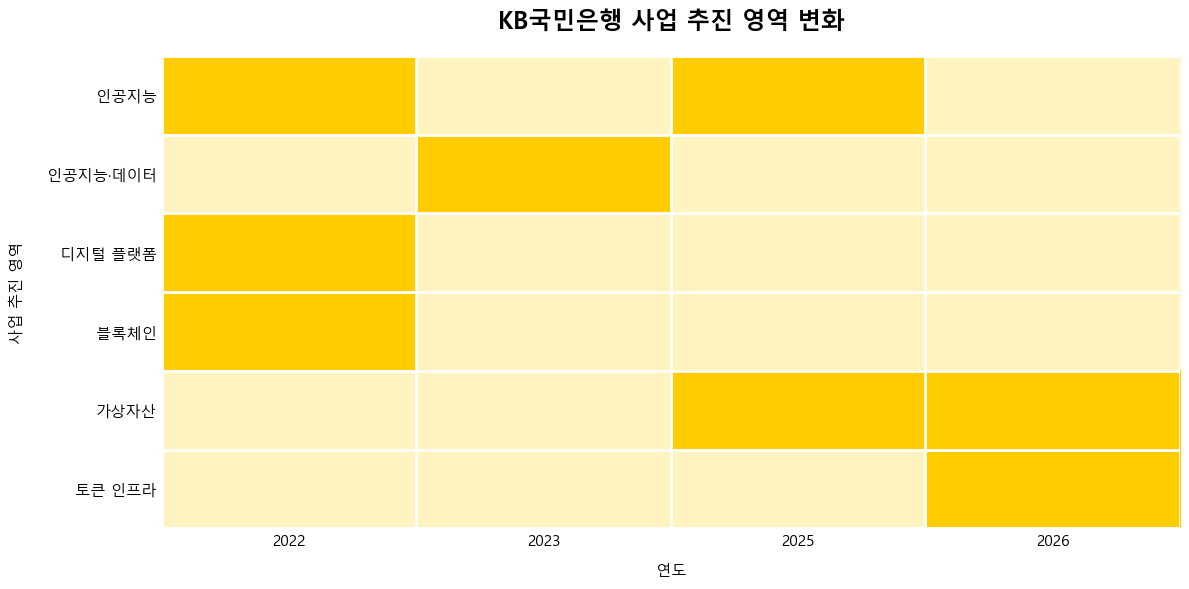

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 사업 영역 한글화
axis_kr = {
    "AI": "인공지능",
    "AI/Data": "인공지능·데이터",
    "Digital Platform": "디지털 플랫폼",
    "Blockchain": "블록체인",
    "Digital Asset": "가상자산",
    "Token Infrastructure": "토큰 인프라"
}

df_kb["사업영역"] = df_kb["business_axis"].map(axis_kr)

# 연도 × 사업영역 존재 여부
pivot = (
    df_kb
    .assign(value=1)
    .pivot_table(
        index="사업영역",
        columns="year",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

# 사업 흐름 순서
order = [
    "인공지능",
    "인공지능·데이터",
    "디지털 플랫폼",
    "블록체인",
    "가상자산",
    "토큰 인프라"
]

pivot = pivot.reindex(
    [x for x in order if x in pivot.index]
)

fig, ax = plt.subplots(figsize=(12, 6))

# 연한 KB Yellow 배경 + 실제 추진 영역 KB Yellow
kb_cmap = ListedColormap([
    "#FFF4BF",   # 미해당 영역
    "#FFCC00"    # 실제 추진 영역
])

ax.imshow(
    pivot.values,
    cmap=kb_cmap,
    aspect="auto",
    vmin=0,
    vmax=1
)

# 축
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

ax.set_title(
    "KB국민은행 사업 추진 영역 변화",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("연도", fontsize=11, labelpad=10)
ax.set_ylabel("사업 추진 영역", fontsize=11, labelpad=15)

# 셀 구분선
ax.set_xticks(
    np.arange(-0.5, len(pivot.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(pivot.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# 외곽선 제거
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

In [6]:
shinhan_data = [
    [2022, "디지털 플랫폼", "디지털·모바일 금융 전환 및 디지털 SI 투자", "확대"],
    
    [2023, "디지털 플랫폼", "그룹 통합앱 신한 슈퍼SOL 출시", "플랫폼 통합"],
    [2023, "인공지능", "AI 음성뱅킹·AI 은행원 등 금융서비스 적용", "서비스 적용"],
    [2023, "AI·블록체인", "디지털 SI 펀드를 통한 AI·블록체인 기업 투자", "투자·확장"],
    
    [2025, "인공지능", "생성형 AI 기반 투자정보 AI PB 서비스", "상용 서비스"],
    [2025, "토큰증권", "투자계약증권 계좌관리기관 참여", "사업화"],
    [2025, "스테이블코인", "스테이블코인 결제 테스트", "실증"],
    
    [2026, "RWA·블록체인", "한국 국채 기반 블록체인 RWA 협업", "인프라 연결"],
    [2026, "토큰증권", "STO 전환을 위한 분산원장 인프라 추진", "인프라 구축"],
    [2026, "AI·Web3", "AX·Web3 Academy 출범 및 디지털자산·수탁 인프라 검토", "사업 확대"]
]

df_shinhan = pd.DataFrame(
    shinhan_data,
    columns=["year", "사업영역", "evidence", "stage"]
)

display(df_shinhan)

,year,사업영역,evidence,stage
0,2022,디지털 플랫폼,디지털·모바일 금융 전환 및 디지털 SI 투자,확대
1,2023,디지털 플랫폼,그룹 통합앱 신한 슈퍼SOL 출시,플랫폼 통합
2,2023,인공지능,AI 음성뱅킹·AI 은행원 등 금융서비스 적용,서비스 적용
3,2023,AI·블록체인,디지털 SI 펀드를 통한 AI·블록체인 기업 투자,투자·확장
4,2025,인공지능,생성형 AI 기반 투자정보 AI PB 서비스,상용 서비스
5,2025,토큰증권,투자계약증권 계좌관리기관 참여,사업화
6,2025,스테이블코인,스테이블코인 결제 테스트,실증
7,2026,RWA·블록체인,한국 국채 기반 블록체인 RWA 협업,인프라 연결
8,2026,토큰증권,STO 전환을 위한 분산원장 인프라 추진,인프라 구축
9,2026,AI·Web3,AX·Web3 Academy 출범 및 디지털자산·수탁 인프라 검토,사업 확대


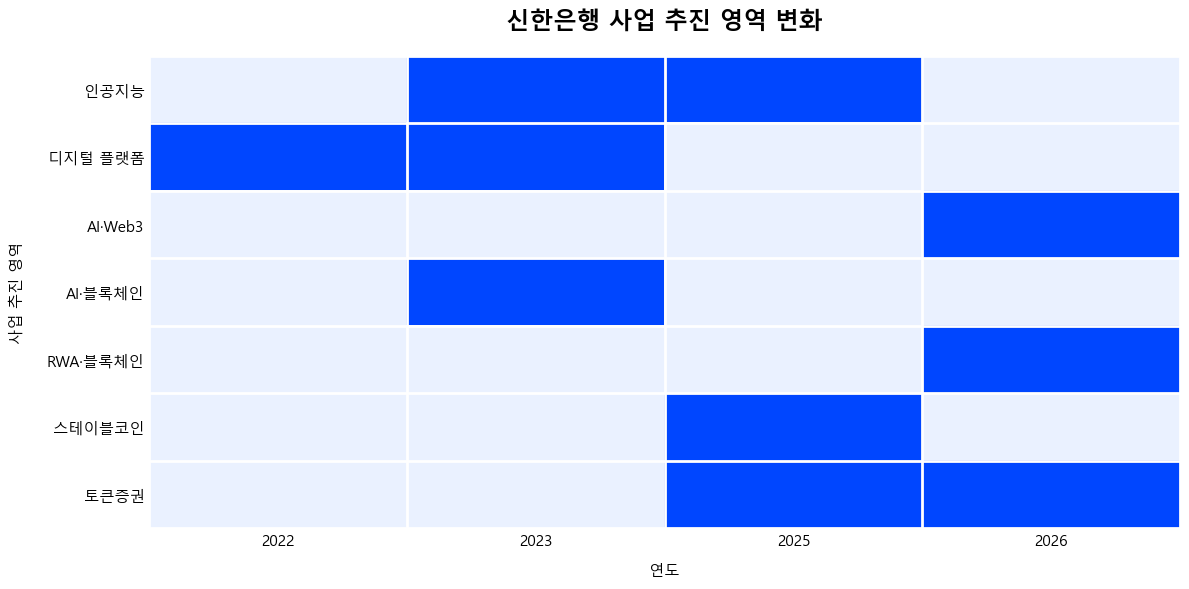

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 연도 × 사업영역 존재 여부
pivot_shinhan = (
    df_shinhan
    .assign(value=1)
    .pivot_table(
        index="사업영역",
        columns="year",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

# 사업 영역 순서
order = [
    "인공지능",
    "인공지능·데이터",
    "디지털 플랫폼",
    "블록체인",
    "가상자산",
    "토큰 인프라"
]

# 실제 데이터에 존재하는 영역만 정렬
existing_order = [x for x in order if x in pivot_shinhan.index]
remaining = [x for x in pivot_shinhan.index if x not in existing_order]

pivot_shinhan = pivot_shinhan.reindex(existing_order + remaining)

fig, ax = plt.subplots(figsize=(12, 6))

# 연한 신한 Blue 배경 + 실제 추진 영역 신한 Blue
shinhan_cmap = ListedColormap([
    "#EAF1FF",   # 미해당 영역
    "#0046FF"    # 실제 추진 영역
])

ax.imshow(
    pivot_shinhan.values,
    cmap=shinhan_cmap,
    aspect="auto",
    vmin=0,
    vmax=1
)

# 축
ax.set_xticks(np.arange(len(pivot_shinhan.columns)))
ax.set_xticklabels(pivot_shinhan.columns, fontsize=11)

ax.set_yticks(np.arange(len(pivot_shinhan.index)))
ax.set_yticklabels(pivot_shinhan.index, fontsize=11)

ax.set_title(
    "신한은행 사업 추진 영역 변화",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("연도", fontsize=11, labelpad=10)
ax.set_ylabel("사업 추진 영역", fontsize=11, labelpad=15)

# 셀 구분선
ax.set_xticks(
    np.arange(-0.5, len(pivot_shinhan.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(pivot_shinhan.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# 외곽선 제거
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

hana_data = [
    [2022, "인공지능·데이터", "AI 기반 금융업무 및 데이터 활용 확대", "업무 적용"],
    [2022, "디지털 플랫폼", "모바일·비대면 금융서비스 확대", "서비스 확대"],

    [2023, "인공지능·데이터", "AI·데이터 기반 디지털 금융 고도화", "고도화"],
    [2023, "디지털 플랫폼", "플랫폼 기반 금융서비스 확대", "플랫폼 확대"],

    [2024, "디지털 플랫폼", "소상공인 디지털 지원 플랫폼 사장님ON 등 확대", "서비스 확대"],
    [2024, "인공지능·데이터", "AI 기반 금융업무 적용 확대", "업무 확대"],

    [2025, "인공지능·데이터", "AI 기반 FDS 등 금융업무 적용 고도화", "고도화"],
    [2025, "디지털자산", "스테이블코인·Web3 결제 등 신사업 검토 확대", "사업 검토"],

    [2026, "인공지능·디지털", "AI디지털혁신그룹 중심 AI·디지털 사업 추진", "조직 확대"],
    [2026, "신사업·디지털", "그룹 신사업·디지털 전담체계 운영", "사업 확대"]
]

df_hana = pd.DataFrame(
    hana_data,
    columns=["year", "사업영역", "evidence", "stage"]
)

display(df_hana)

,year,사업영역,evidence,stage
0,2022,인공지능·데이터,AI 기반 금융업무 및 데이터 활용 확대,업무 적용
1,2022,디지털 플랫폼,모바일·비대면 금융서비스 확대,서비스 확대
2,2023,인공지능·데이터,AI·데이터 기반 디지털 금융 고도화,고도화
3,2023,디지털 플랫폼,플랫폼 기반 금융서비스 확대,플랫폼 확대
4,2024,디지털 플랫폼,소상공인 디지털 지원 플랫폼 사장님ON 등 확대,서비스 확대
5,2024,인공지능·데이터,AI 기반 금융업무 적용 확대,업무 확대
6,2025,인공지능·데이터,AI 기반 FDS 등 금융업무 적용 고도화,고도화
7,2025,디지털자산,스테이블코인·Web3 결제 등 신사업 검토 확대,사업 검토
8,2026,인공지능·디지털,AI디지털혁신그룹 중심 AI·디지털 사업 추진,조직 확대
9,2026,신사업·디지털,그룹 신사업·디지털 전담체계 운영,사업 확대


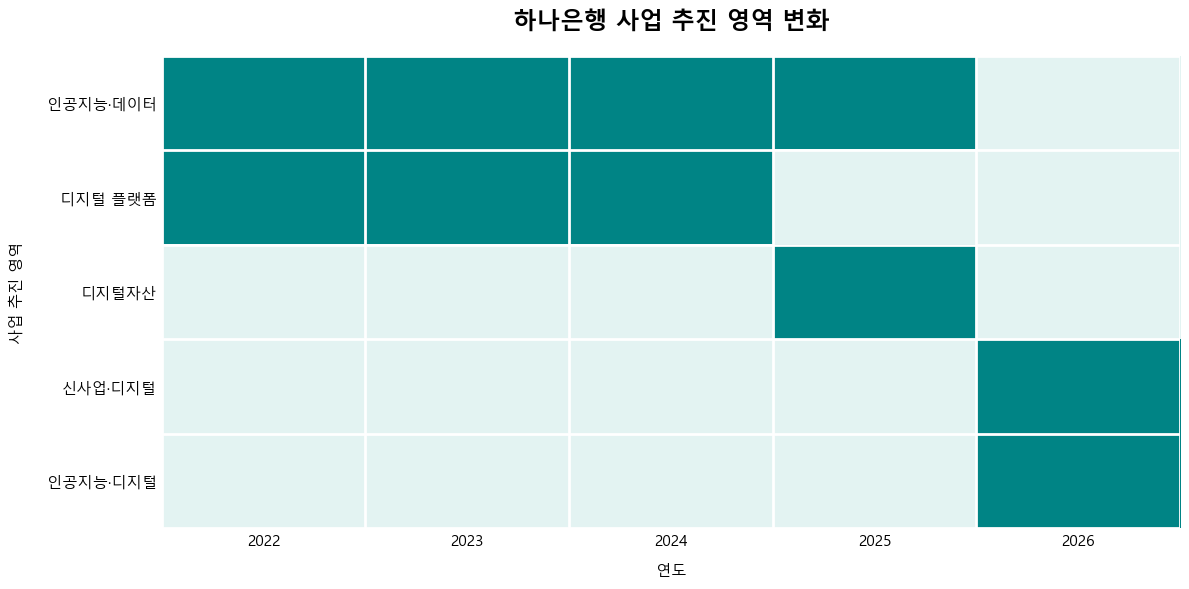

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 연도 × 사업영역 존재 여부
pivot_hana = (
    df_hana
    .assign(value=1)
    .pivot_table(
        index="사업영역",
        columns="year",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

# 사업 영역 순서
order = [
    "인공지능",
    "인공지능·데이터",
    "디지털 플랫폼",
    "블록체인",
    "가상자산",
    "토큰 인프라"
]

# 실제 데이터에 존재하는 영역만 정렬
existing_order = [x for x in order if x in pivot_hana.index]
remaining = [x for x in pivot_hana.index if x not in existing_order]

pivot_hana = pivot_hana.reindex(existing_order + remaining)

fig, ax = plt.subplots(figsize=(12, 6))

# 연한 하나 Teal 배경 + 실제 추진 영역 하나 Teal
hana_cmap = ListedColormap([
    "#E3F3F2",   # 미해당 영역
    "#008485"    # 실제 추진 영역
])

ax.imshow(
    pivot_hana.values,
    cmap=hana_cmap,
    aspect="auto",
    vmin=0,
    vmax=1
)

# 축
ax.set_xticks(np.arange(len(pivot_hana.columns)))
ax.set_xticklabels(pivot_hana.columns, fontsize=11)

ax.set_yticks(np.arange(len(pivot_hana.index)))
ax.set_yticklabels(pivot_hana.index, fontsize=11)

ax.set_title(
    "하나은행 사업 추진 영역 변화",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("연도", fontsize=11, labelpad=10)
ax.set_ylabel("사업 추진 영역", fontsize=11, labelpad=15)

# 셀 구분선
ax.set_xticks(
    np.arange(-0.5, len(pivot_hana.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(pivot_hana.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# 외곽선 제거
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

woori_data = [
    [2022, "인공지능·데이터", "그룹 데이터·AI 총괄 DI기획부 및 은행 DI기획 ACT 신설", "조직 구축"],
    [2022, "디지털 플랫폼", "디지털 유니버셜 뱅크 추진", "플랫폼 구축"],

    [2024, "디지털 플랫폼", "디지털 금융서비스 및 그룹 디지털 전략 확대", "서비스 확대"],
    [2024, "데이터·정보보호", "디지털 전환에 따른 데이터·정보보호 체계 강화", "고도화"],

    [2025, "인공지능", "AI뱅커·우리GPT 등 생성형 AI 금융업무 적용", "상용화"],
    [2025, "클라우드", "그룹 공동 클라우드 플랫폼 구축 및 전 계열사 확대", "인프라 구축"],
    [2025, "디지털 플랫폼", "우리WON MTS 출시 및 디지털 종합금융 플랫폼 확대", "사업 확대"],
    [2025, "AI·SaaS", "생성형 AI 및 SaaS 활용 보안 가이드 마련", "통제체계 구축"],

    [2026, "인공지능·AX", "금융 AX 혁신을 그룹 핵심 경영 아젠다로 확대", "전사 확대"]
]

df_woori = pd.DataFrame(
    woori_data,
    columns=["year", "사업영역", "evidence", "stage"]
)

display(df_woori)

,year,사업영역,evidence,stage
0,2022,인공지능·데이터,그룹 데이터·AI 총괄 DI기획부 및 은행 DI기획 ACT 신설,조직 구축
1,2022,디지털 플랫폼,디지털 유니버셜 뱅크 추진,플랫폼 구축
2,2024,디지털 플랫폼,디지털 금융서비스 및 그룹 디지털 전략 확대,서비스 확대
3,2024,데이터·정보보호,디지털 전환에 따른 데이터·정보보호 체계 강화,고도화
4,2025,인공지능,AI뱅커·우리GPT 등 생성형 AI 금융업무 적용,상용화
5,2025,클라우드,그룹 공동 클라우드 플랫폼 구축 및 전 계열사 확대,인프라 구축
6,2025,디지털 플랫폼,우리WON MTS 출시 및 디지털 종합금융 플랫폼 확대,사업 확대
7,2025,AI·SaaS,생성형 AI 및 SaaS 활용 보안 가이드 마련,통제체계 구축
8,2026,인공지능·AX,금융 AX 혁신을 그룹 핵심 경영 아젠다로 확대,전사 확대


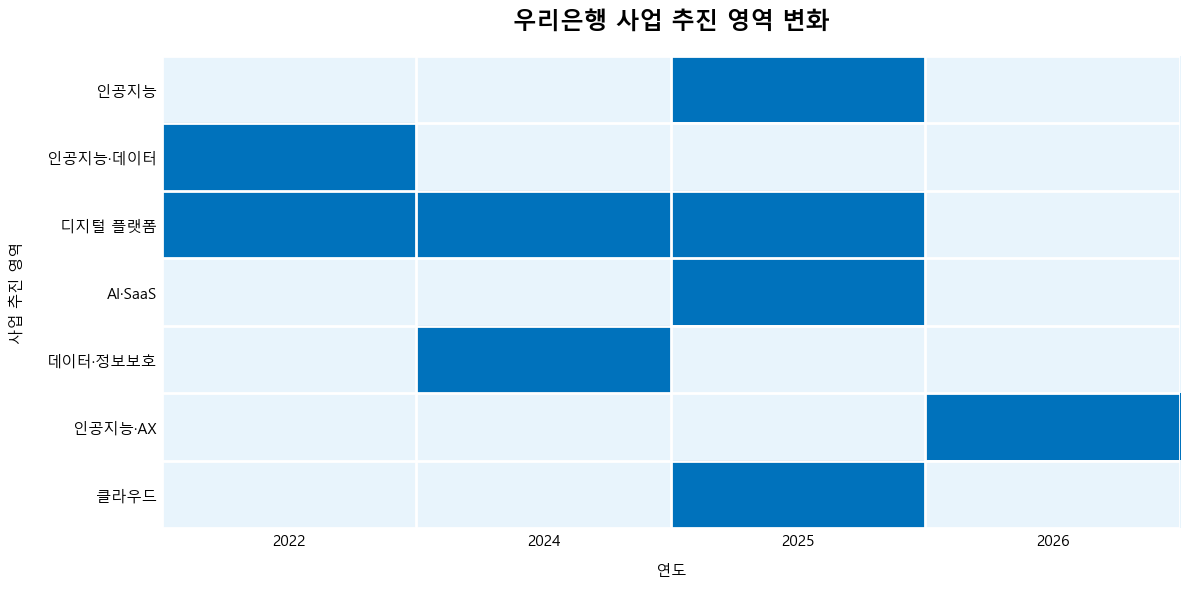

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 연도 × 사업영역 존재 여부
pivot_woori = (
    df_woori
    .assign(value=1)
    .pivot_table(
        index="사업영역",
        columns="year",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

# 사업 영역 순서
order = [
    "인공지능",
    "인공지능·데이터",
    "디지털 플랫폼",
    "블록체인",
    "가상자산",
    "토큰 인프라"
]

# 실제 데이터에 존재하는 영역만 정렬
existing_order = [x for x in order if x in pivot_woori.index]
remaining = [x for x in pivot_woori.index if x not in existing_order]

pivot_woori = pivot_woori.reindex(existing_order + remaining)

fig, ax = plt.subplots(figsize=(12, 6))

# 연한 우리은행 Blue 배경 + 실제 추진 영역 우리은행 Blue
woori_cmap = ListedColormap([
    "#E8F4FC",   # 미해당 영역
    "#0072BC"    # 실제 추진 영역
])

ax.imshow(
    pivot_woori.values,
    cmap=woori_cmap,
    aspect="auto",
    vmin=0,
    vmax=1
)

# 축
ax.set_xticks(np.arange(len(pivot_woori.columns)))
ax.set_xticklabels(pivot_woori.columns, fontsize=11)

ax.set_yticks(np.arange(len(pivot_woori.index)))
ax.set_yticklabels(pivot_woori.index, fontsize=11)

ax.set_title(
    "우리은행 사업 추진 영역 변화",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("연도", fontsize=11, labelpad=10)
ax.set_ylabel("사업 추진 영역", fontsize=11, labelpad=15)

# 셀 구분선
ax.set_xticks(
    np.arange(-0.5, len(pivot_woori.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(pivot_woori.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# 외곽선 제거
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

In [23]:
nh_data = [
    [2022, "디지털 혁신", "NH디지털혁신캠퍼스 기반 디지털 금융 혁신 추진", "인프라 운영"],
    [2022, "인공지능·데이터", "AI·데이터 기반 금융서비스 및 업무혁신 추진", "업무 적용"],
    [2022, "블록체인", "디지털 R&D에서 블록체인 등 신기술 연구", "기술 연구"],

    [2023, "디지털 플랫폼", "NH올원뱅크 중심 비대면 금융서비스 확대", "플랫폼 확대"],
    [2023, "인공지능·데이터", "AI·데이터 활용 금융업무 확대", "업무 확대"],

    [2024, "디지털 플랫폼", "모바일 금융 및 디지털 채널 고도화", "고도화"],
    [2024, "인공지능·데이터", "AI 기반 업무 및 고객서비스 확대", "서비스 확대"],

    [2025, "인공지능·데이터", "AI 기반 금융서비스·업무혁신 확대", "고도화"],
    [2025, "디지털 플랫폼", "디지털 금융 플랫폼 및 고객서비스 고도화", "고도화"],

    [2026, "디지털 혁신", "디지털 금융 및 신기술 기반 사업 확대", "사업 확대"]
]

df_nh = pd.DataFrame(
    nh_data,
    columns=["year", "사업영역", "evidence", "stage"]
)

display(df_nh)

,year,사업영역,evidence,stage
0,2022,디지털 혁신,NH디지털혁신캠퍼스 기반 디지털 금융 혁신 추진,인프라 운영
1,2022,인공지능·데이터,AI·데이터 기반 금융서비스 및 업무혁신 추진,업무 적용
2,2022,블록체인,디지털 R&D에서 블록체인 등 신기술 연구,기술 연구
3,2023,디지털 플랫폼,NH올원뱅크 중심 비대면 금융서비스 확대,플랫폼 확대
4,2023,인공지능·데이터,AI·데이터 활용 금융업무 확대,업무 확대
5,2024,디지털 플랫폼,모바일 금융 및 디지털 채널 고도화,고도화
6,2024,인공지능·데이터,AI 기반 업무 및 고객서비스 확대,서비스 확대
7,2025,인공지능·데이터,AI 기반 금융서비스·업무혁신 확대,고도화
8,2025,디지털 플랫폼,디지털 금융 플랫폼 및 고객서비스 고도화,고도화
9,2026,디지털 혁신,디지털 금융 및 신기술 기반 사업 확대,사업 확대


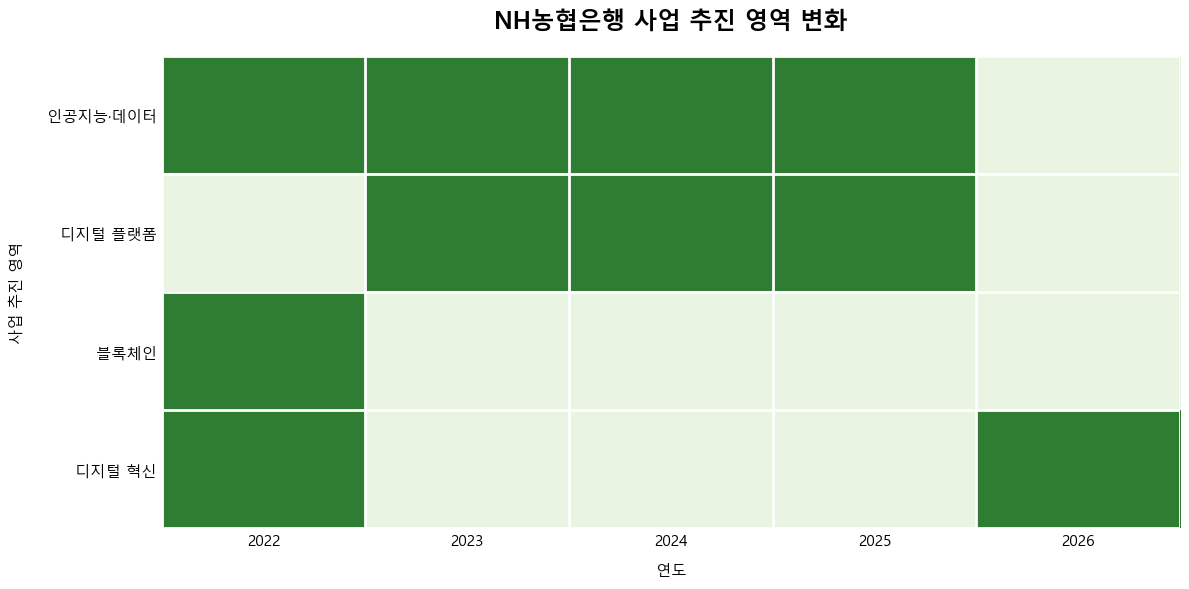

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 연도 × 사업영역 존재 여부
pivot_nh = (
    df_nh
    .assign(value=1)
    .pivot_table(
        index="사업영역",
        columns="year",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

# 사업 영역 순서
order = [
    "인공지능",
    "인공지능·데이터",
    "디지털 플랫폼",
    "블록체인",
    "가상자산",
    "토큰 인프라"
]

# 실제 데이터에 존재하는 영역만 정렬
existing_order = [x for x in order if x in pivot_nh.index]
remaining = [x for x in pivot_nh.index if x not in existing_order]

pivot_nh = pivot_nh.reindex(existing_order + remaining)

fig, ax = plt.subplots(figsize=(12, 6))

# 연한 NH Green 배경 + 실제 추진 영역 NH Green
nh_cmap = ListedColormap([
    "#EAF4E3",   # 미해당 영역
    "#2F7D32"    # 실제 추진 영역
])

ax.imshow(
    pivot_nh.values,
    cmap=nh_cmap,
    aspect="auto",
    vmin=0,
    vmax=1
)

# 축
ax.set_xticks(np.arange(len(pivot_nh.columns)))
ax.set_xticklabels(pivot_nh.columns, fontsize=11)

ax.set_yticks(np.arange(len(pivot_nh.index)))
ax.set_yticklabels(pivot_nh.index, fontsize=11)

ax.set_title(
    "NH농협은행 사업 추진 영역 변화",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("연도", fontsize=11, labelpad=10)
ax.set_ylabel("사업 추진 영역", fontsize=11, labelpad=15)

# 셀 구분선
ax.set_xticks(
    np.arange(-0.5, len(pivot_nh.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(pivot_nh.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# 외곽선 제거
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

In [26]:

# 00. 5대 은행 사업 추진 흐름 통합
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 은행명 부여
df_kb["은행"] = "KB국민"
df_shinhan["은행"] = "신한"
df_hana["은행"] = "하나"
df_woori["은행"] = "우리"
df_nh["은행"] = "NH농협"

# 컬럼명 통일
if "business_axis" in df_kb.columns:
    df_kb["사업영역"] = df_kb["business_axis"].replace({
        "AI": "인공지능·데이터",
        "AI/Data": "인공지능·데이터",
        "Digital Platform": "디지털 플랫폼",
        "Blockchain": "블록체인·디지털자산",
        "Digital Asset": "블록체인·디지털자산",
        "Token Infrastructure": "토큰화 금융"
    })

# 통합
df_all = pd.concat(
    [df_kb, df_shinhan, df_hana, df_woori, df_nh],
    ignore_index=True
)

# 너무 잘게 나뉜 사업영역 → 공통 사업축으로 통일


def normalize_axis(x):
    x = str(x)

    if any(k in x for k in ["AI", "인공지능", "데이터", "AX"]):
        return "AI·데이터"

    if any(k in x for k in ["클라우드", "SaaS", "플랫폼", "디지털 혁신"]):
        return "디지털 플랫폼·인프라"

    if any(k in x for k in [
        "가상자산", "디지털자산", "블록체인",
        "Web3", "스테이블코인"
    ]):
        return "블록체인·디지털자산"

    if any(k in x for k in [
        "토큰", "RWA", "토큰증권"
    ]):
        return "토큰화 금융"

    return "기타"

df_all["통합사업축"] = df_all["사업영역"].apply(normalize_axis)

display(
    df_all[
        ["은행", "year", "통합사업축", "evidence", "stage"]
    ].sort_values(["year", "은행"])
)

,은행,year,통합사업축,evidence,stage
0,KB국민,2022,AI·데이터,AI은행원·AI금융비서·AI-OCR·기업여신 자동심사,업무 적용
1,KB국민,2022,디지털 플랫폼·인프라,AI 챗봇·클라우드 기반 FCC 구축,인프라 구축
2,KB국민,2022,블록체인·디지털자산,블록체인 기술협력,기술 탐색
37,NH농협,2022,디지털 플랫폼·인프라,NH디지털혁신캠퍼스 기반 디지털 금융 혁신 추진,인프라 운영
38,NH농협,2022,AI·데이터,AI·데이터 기반 금융서비스 및 업무혁신 추진,업무 적용
39,NH농협,2022,블록체인·디지털자산,디지털 R&D에서 블록체인 등 신기술 연구,기술 연구
8,신한,2022,디지털 플랫폼·인프라,디지털·모바일 금융 전환 및 디지털 SI 투자,확대
28,우리,2022,AI·데이터,그룹 데이터·AI 총괄 DI기획부 및 은행 DI기획 ACT 신설,조직 구축
29,우리,2022,디지털 플랫폼·인프라,디지털 유니버셜 뱅크 추진,플랫폼 구축
18,하나,2022,AI·데이터,AI 기반 금융업무 및 데이터 활용 확대,업무 적용


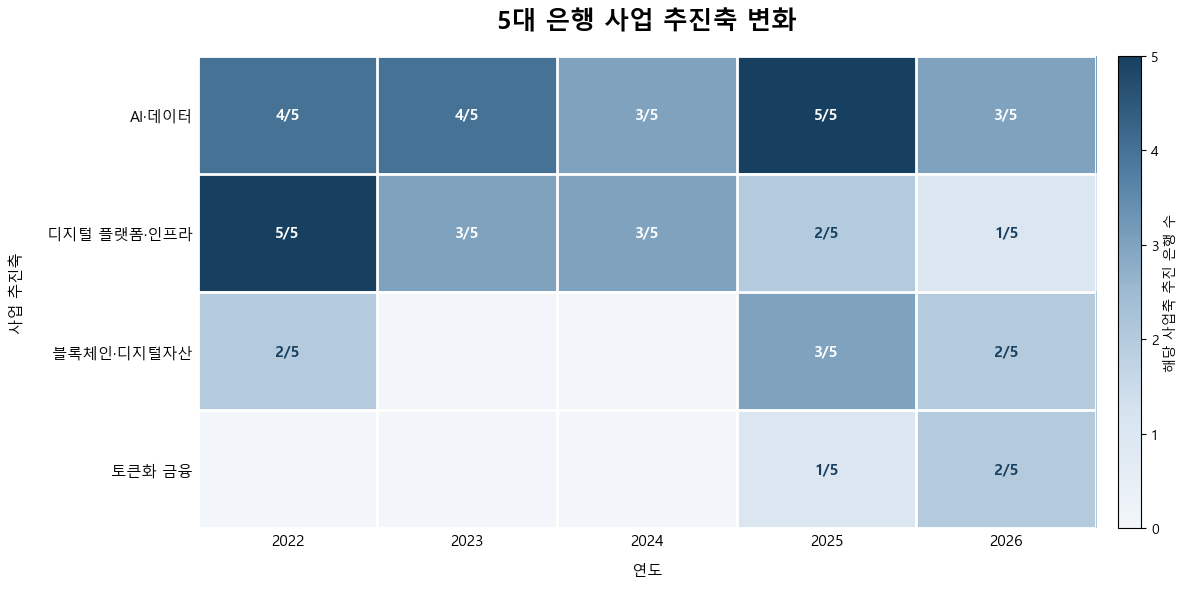

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 같은 은행이 같은 연도·사업축에 여러 사례가 있어도 1개 은행으로 계산
bank_axis = (
    df_all[
        ["은행", "year", "통합사업축"]
    ]
    .drop_duplicates()
)

# 연도별 해당 사업축에 진입한 은행 수
pivot_all = (
    bank_axis
    .groupby(["통합사업축", "year"])["은행"]
    .nunique()
    .unstack(fill_value=0)
)

# 사업 흐름 순서
order = [
    "AI·데이터",
    "디지털 플랫폼·인프라",
    "블록체인·디지털자산",
    "토큰화 금융"
]

pivot_all = pivot_all.reindex(
    [x for x in order if x in pivot_all.index]
)

fig, ax = plt.subplots(figsize=(13, 6))

# 금융권 통합 차트용 Navy 계열
cmap = LinearSegmentedColormap.from_list(
    "finance",
    [
        "#F2F6FA",
        "#D6E3EF",
        "#9EBBD2",
        "#527FA3",
        "#173F5F"
    ]
)

im = ax.imshow(
    pivot_all.values,
    cmap=cmap,
    aspect="auto",
    vmin=0,
    vmax=5
)

# 셀 안에 진입 은행 수 표시
for i in range(len(pivot_all.index)):
    for j in range(len(pivot_all.columns)):
        value = int(pivot_all.iloc[i, j])

        if value > 0:
            ax.text(
                j,
                i,
                f"{value}/5",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if value >= 3 else "#173F5F"
            )

# 축
ax.set_xticks(np.arange(len(pivot_all.columns)))
ax.set_xticklabels(pivot_all.columns, fontsize=11)

ax.set_yticks(np.arange(len(pivot_all.index)))
ax.set_yticklabels(pivot_all.index, fontsize=11)

ax.set_title(
    "5대 은행 사업 추진축 변화",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("연도", fontsize=11, labelpad=10)
ax.set_ylabel("사업 추진축", fontsize=11, labelpad=15)

# 셀 구분선
ax.set_xticks(
    np.arange(-0.5, len(pivot_all.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(pivot_all.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

# 색상 의미
cbar = plt.colorbar(
    im,
    ax=ax,
    pad=0.02,
    ticks=[0, 1, 2, 3, 4, 5]
)

cbar.set_label(
    "해당 사업축 추진 은행 수",
    fontsize=10
)

plt.tight_layout()
plt.show()

# 참고문헌

KB국민은행·KB금융그룹. 「사업보고서」 및 「Annual Report」, 2022–2026.
신한은행·신한금융그룹. 「사업보고서」 및 「Annual Report」, 2022–2026.
하나은행·하나금융그룹. 「사업보고서」 및 「Annual Report」, 2022–2026.
우리은행·우리금융그룹. 「사업보고서」 및 「Annual Report」, 2022–2026.
NH농협은행·NH농협금융지주. 「사업보고서」·「Annual Report」 및 경영공시, 2022–2026.

※ 본 분석은 5대 은행 및 금융그룹의 공식 공시자료에서 AI·Data, SaaS·Cloud,
Blockchain·Digital Asset, Token Infrastructure 관련 사업 추진 사례를 추출·분류하였다.
사례 수 자체보다 연도별 사업 추진 영역의 변화와 확장 방향을 분석하는 데 목적이 있다.